# Assignment 4 — Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Objective:** Predict whether a breast tumor is Malignant (M) or Benign (B) based on diagnostic measurements, using a K-Nearest Neighbors classifier.

**Dataset:** [Breast Cancer Wisconsin Diagnostic Dataset](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) (Kaggle)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (make sure the CSV is in the same folder as this notebook)
# The Kaggle file is typically named: data.csv
df = pd.read_csv("data.csv")

# Display the first five records
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [3]:
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Identifying feature types

- **Numerical features:** all diagnostic measurement columns (`radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`, and their `_se` and `_worst` counterparts, etc.)
- **Target variable:** `diagnosis` (M = Malignant, B = Benign)
- **Columns to drop:** `id` (unique identifier, not predictive) and `Unnamed: 32` (an empty column present in the raw Kaggle CSV due to a trailing comma)


## Task 2: Data Preprocessing

In [4]:
# Check for missing values
print(df.isnull().sum())


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
# Remove unnecessary columns
# 'id' is just a unique identifier; 'Unnamed: 32' is an empty artifact column from the raw CSV
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())


Remaining columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [6]:
# Encode the target variable: M (Malignant) -> 1, B (Benign) -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (569, 30)
Target shape: (569,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize feature values - important for KNN since it relies on distance calculations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


## Task 3: Model Development

In [8]:
from sklearn.neighbors import KNeighborsClassifier

# Train a K-Nearest Neighbors classifier with K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict class labels for the test dataset
y_pred = knn.predict(X_test_scaled)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test.values[:10])


Predicted labels: [0 1 0 0 0 0 1 0 0 0]
Actual labels:    [0 1 0 1 0 0 1 0 0 0]


## Task 4: Model Evaluation

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1-Score: 0.9383


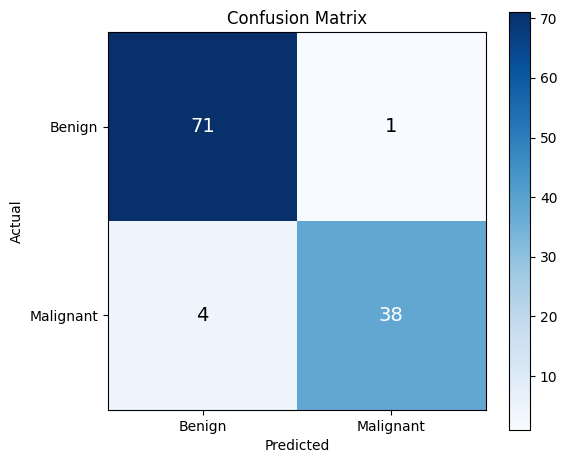

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.yticks([0, 1], ['Benign', 'Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


### Observations

1. The model achieves an accuracy of 0.9561, correctly classifying about 96% of tumors as Malignant or Benign — a strong result for this dataset.
2. Precision (0.9744) is higher than Recall (0.9048), meaning that when the model predicts "Malignant," it's very often correct, but it still misses a small number of actual Malignant cases (classifying them as Benign). In a medical context, these missed cases (false negatives) are the more concerning error type, since a missed diagnosis delays treatment.
3. The F1-Score of 0.9383 confirms a strong overall balance between precision and recall, though the gap between them suggests there's still room to reduce false negatives, possibly by tuning K or exploring feature importance further.


## Task 5: Conclusion

This project used a K-Nearest Neighbors (K=5) classifier to predict whether a breast tumor is Malignant or Benign based on diagnostic measurements. After preprocessing the data (removing the non-predictive id column and the empty Unnamed: 32 artifact column, encoding the diagnosis label, and standardizing all features), the model achieved an accuracy of 0.9561, precision of 0.9744, recall of 0.9048, and an F1-score of 0.9383 on the test set — a strong result overall, though recall being somewhat lower than precision indicates a small number of Malignant cases were missed.

Feature scaling was essential for this model, since KNN classifies new points based on the distance to their nearest neighbors. Without standardization, features with naturally larger numeric ranges, such as area_mean (which reaches into the thousands), would dominate the distance calculation over features with smaller ranges, such as smoothness_mean (values under 1), regardless of each feature's actual diagnostic importance.

A key limitation of KNN is that it must compute the distance to every training point for each new prediction, making it computationally expensive as the dataset grows, and it treats all features as equally important unless explicitly weighted, making it sensitive to irrelevant or noisy features.